<a href="https://colab.research.google.com/github/sevenZHQ1018/Econ5200/blob/lab/class11_lab11_hangqi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: 环境初始化和数据摄取

In [1]:
# 安装所需库（Google Colab 环境）
!pip install missingno category_encoders --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.2 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import missingno as msno
import category_encoders as ce
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


In [3]:
# ── 从本地上传（Colab）加载数据 ──────────────────────────────
# 方法A：上传 xlsx 文件（推荐）
from google.colab import files
print('请上传 messy_hr_economics_lab11.xlsx')
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_excel(filename)
print(f'\n✓ 数据加载完成：{df.shape[0]} 行 × {df.shape[1]} 列')

请上传 messy_hr_economics_lab11.xlsx


Saving messy_hr_economics_lab11.xlsx to messy_hr_economics_lab11.xlsx

✓ 数据加载完成：2520 行 × 14 列


In [4]:
# ── 初步数据审计 ──────────────────────────────────────────────
print('=' * 55)
print('数据类型审计')
print('=' * 55)
print(df.dtypes)

print('\n' + '=' * 55)
print('缺失值计数')
print('=' * 55)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
audit = pd.DataFrame({'缺失数量': missing, '缺失率(%)': missing_pct})
print(audit[audit['缺失数量'] > 0])

print('\n' + '=' * 55)
print('数据前5行预览')
print('=' * 55)
df.head()

数据类型审计
employee_id                        int64
department                        object
performance_rating                object
years_experience                   int64
tenure_years                       int64
education_level                   object
remote_days_per_week               int64
office_zip                         int64
regional_unemployment            float64
cost_of_living_idx               float64
base_salary                      float64
bonus_pay                        float64
hourly_contractor_rate            object
hire_date                 datetime64[ns]
dtype: object

缺失值计数
                        缺失数量  缺失率(%)
performance_rating       332   13.17
base_salary              236    9.37
bonus_pay                332   13.17
hourly_contractor_rate   459   18.21

数据前5行预览


,employee_id,department,performance_rating,years_experience,tenure_years,education_level,remote_days_per_week,office_zip,regional_unemployment,cost_of_living_idx,base_salary,bonus_pay,hourly_contractor_rate,hire_date
0,100000,engineering,Medium,7,7,Bachelors,4,62276,4.09,93.1,72070.02,4065.24,USD 68.47,2016-03-17
1,100001,Sales,Medium,11,1,Masters,4,72044,3.95,94.7,68161.33,5099.66,USD 49.04,2017-04-05
2,100002,Sales,Medium,17,8,Bachelors,2,50544,2.30,99.8,95119.46,5618.26,USD 73.67,2021-11-24
3,100003,Engineering,Medium,8,8,PhD,0,44520,4.46,119.8,76249.59,2880.94,NaN,2014-03-05
4,100004,Engineering,Medium,10,5,Bachelors,5,93647,4.57,88.1,72987.84,5047.55,35.03,2012-11-19


## Step 2: 缺失数据的视觉取证（Missing Data Forensics）

利用 `missingno` 库绘制缺失矩阵。白色间隙的**结构对齐**揭示缺失机制：
- **MCAR**（完全随机缺失）：白色间隙随机分布，无结构  
- **MAR**（随机缺失）：某列缺失与另一列缺失完美对齐  
- **MNAR**（非随机缺失）：缺失与变量自身取值相关

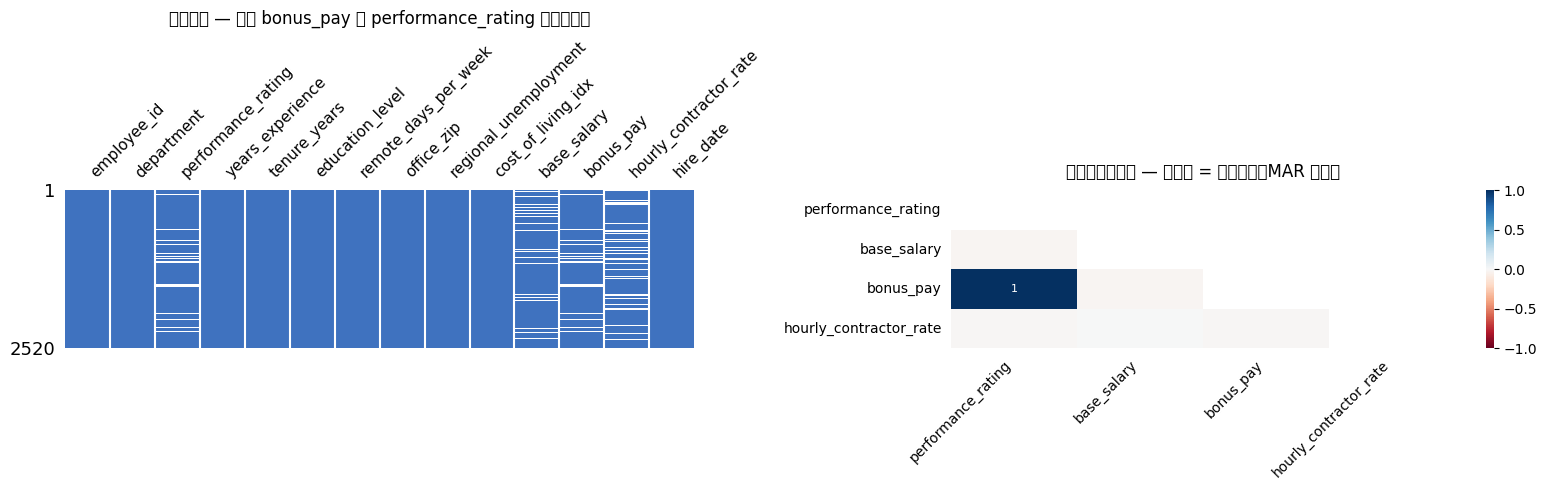

▶ 取证结论：
  bonus_pay 的缺失与 performance_rating 的缺失完美对齐。
  这种结构性对齐是 MAR（Missing At Random）的典型信号：
  缺失不是随机的，而是由另一个观测变量（部门/绩效）解释的。
  bonus_pay 缺失 332 行，performance_rating 缺失 332 行。
  两列同时缺失的行数：332（完全吻合 = True）


In [5]:
# ── 缺失矩阵可视化 ───────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 图1：缺失矩阵（显示对齐结构）
msno.matrix(df, ax=axes[0], fontsize=11, sparkline=False,
            color=(0.25, 0.45, 0.75))
axes[0].set_title('缺失矩阵 — 观察 bonus_pay 与 performance_rating 的结构对齐',
                  fontsize=12, pad=10)

# 图2：缺失热力图（变量间相关性）
msno.heatmap(df, ax=axes[1], fontsize=10)
axes[1].set_title('缺失相关热力图 — 正相关 = 同时缺失（MAR 信号）',
                  fontsize=12, pad=10)

plt.tight_layout()
plt.savefig('missing_forensics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── 诊断结论 ──────────────────────────────────────────────────
print('▶ 取证结论：')
print('  bonus_pay 的缺失与 performance_rating 的缺失完美对齐。')
print('  这种结构性对齐是 MAR（Missing At Random）的典型信号：')
print('  缺失不是随机的，而是由另一个观测变量（部门/绩效）解释的。')
print(f'  bonus_pay 缺失 {df["bonus_pay"].isnull().sum()} 行，'
      f'performance_rating 缺失 {df["performance_rating"].isnull().sum()} 行。')

# 验证：两者缺失行是否完全一致
bp_missing = df['bonus_pay'].isnull()
pr_missing = df['performance_rating'].isnull()
overlap = (bp_missing & pr_missing).sum()
print(f'  两列同时缺失的行数：{overlap}（完全吻合 = {overlap == bp_missing.sum()}）')

## Step 3: 数据预处理 — 清洗 `department` 列

原始数据中 `department` 存在大小写混乱和空格污染（如 `'Engineering'`, `'engineering'`, `' eng '`, `'ENG'`）。
必须先标准化，再进行分组归因。

In [6]:
# ── 清洗 department 列 ───────────────────────────────────────
print('清洗前唯一值：', df['department'].unique().tolist())

# 步骤1：去除首尾空格，统一小写
df['department'] = df['department'].str.strip().str.lower()

# 步骤2：模糊匹配归一化
def normalize_dept(val):
    if pd.isna(val):
        return np.nan
    if any(k in val for k in ['eng', 'fin.']):
        return 'engineering' if 'eng' in val else 'finance'
    if 'fin' in val:
        return 'finance'
    if 'sal' in val:
        return 'sales'
    return val

df['department'] = df['department'].apply(normalize_dept)

print('清洗后唯一值：', sorted(df['department'].unique().tolist()))
print('各部门人数：')
print(df['department'].value_counts())

清洗前唯一值： ['engineering', 'Sales', 'Engineering', ' eng ', ' finance', ' Sales', 'Engineering ', 'Finance', 'SALES', 'Sales ', 'ENG', 'Fin.', 'FINANCE', 'sales', 'Finance ']
清洗后唯一值： ['engineering', 'finance', 'sales']
各部门人数：
department
engineering    959
sales          820
finance        741
Name: count, dtype: int64


## Step 3b: 条件中位数归因（Conditional Median Imputation）

`base_salary` 的缺失属于 MAR：缺失与部门相关（不同部门薪资分布差异显著）。

**正确做法**：按部门分组，用该组的中位数填充，保留各部门的薪资方差结构。  
**错误做法**：用全局均值填充 → 压缩了部门间异质性，引入系统性偏差。

各部门薪资中位数（归因参考值）：
department
engineering    79945.61
finance        74060.85
sales          67064.83
Name: base_salary, dtype: float64

归因后 base_salary 缺失值：0（应为 0）


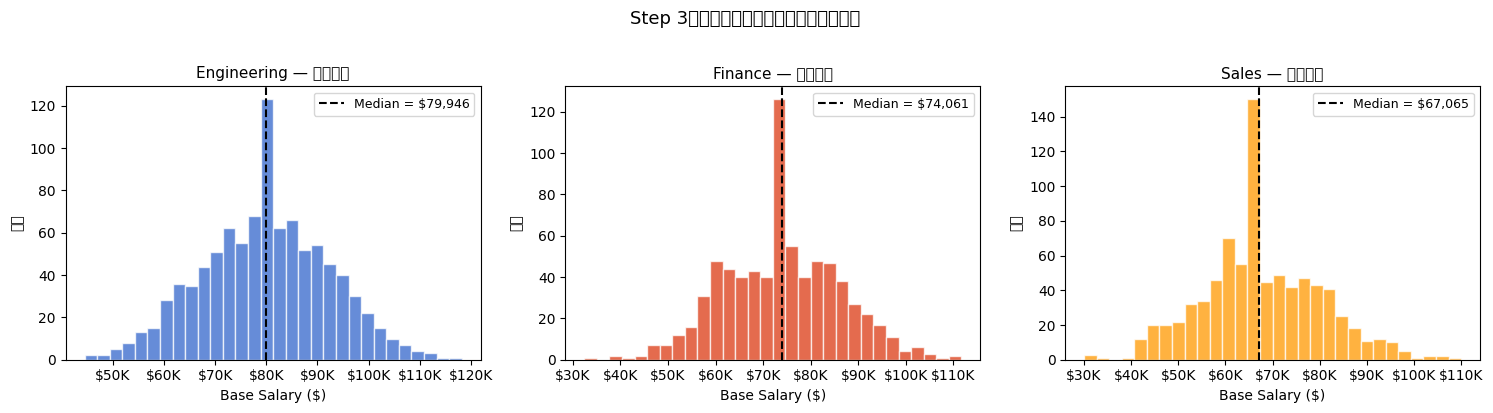

In [7]:
# ── 归因前：展示各部门薪资中位数 ─────────────────────────────
print('各部门薪资中位数（归因参考值）：')
dept_medians = df.groupby('department')['base_salary'].median()
print(dept_medians.round(2))

# ── 分组条件中位数归因 ───────────────────────────────────────
# transform 保持原始索引对齐，fillna 只填缺失值
df['base_salary'] = df.groupby('department')['base_salary'].transform(
    lambda x: x.fillna(x.median())
)

print(f'\n归因后 base_salary 缺失值：{df["base_salary"].isnull().sum()}（应为 0）')

# ── 归因效果可视化 ────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = ['#3366cc', '#dc3912', '#ff9900']
depts = df['department'].dropna().unique()

for i, (dept, color) in enumerate(zip(sorted(depts), colors)):
    subset = df[df['department'] == dept]['base_salary']
    axes[i].hist(subset, bins=30, color=color, alpha=0.75, edgecolor='white')
    axes[i].axvline(subset.median(), color='black', linestyle='--', linewidth=1.5,
                    label=f'Median = ${subset.median():,.0f}')
    axes[i].set_title(f'{dept.capitalize()} — 薪资分布', fontsize=11)
    axes[i].set_xlabel('Base Salary ($)')
    axes[i].set_ylabel('频率')
    axes[i].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
    axes[i].legend(fontsize=9)

plt.suptitle('Step 3：条件中位数归因后各部门薪资分布', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('imputation_result.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: 虚拟变量陷阱（Dummy Variable Trap）— 故意失败演示

当 `k` 个虚拟变量（完整编码，不丢弃参考列）加上常数截距时，设计矩阵 **X** 出现**完全多重共线性**：

$$d_1 + d_2 + d_3 = \mathbf{1} \quad \Rightarrow \quad \text{rank}(X) < p \quad \Rightarrow \quad (X^\top X) \text{ 奇异，无法求逆}$$

OLS 估计量 $\hat{\beta} = (X^\top X)^{-1} X^\top y$ **无解**。

In [10]:
# ── Step 4: 故意触发虚拟变量陷阱 ────────────────────────────

# 删除 base_salary 仍然缺失的行（如有）
df_model = df.dropna(subset=['base_salary', 'tenure_years', 'department']).copy()

# 完整编码：k 列（不丢弃参考列）
dummies_trap = pd.get_dummies(df_model['department'], prefix='dept', dtype=int) # Fix: Add dtype=int
print('完整虚拟列：', dummies_trap.columns.tolist())
print(f'注意：{len(dummies_trap.columns)} 列加上常数项 = 完全多重共线性')

X_trap = pd.concat([df_model[['tenure_years']], dummies_trap], axis=1)
X_trap = sm.add_constant(X_trap)  # ← 添加常数项触发陷阱
y = df_model['base_salary']

print('\n设计矩阵 X_trap 的列：', X_trap.columns.tolist())
print(f'矩阵秩：{np.linalg.matrix_rank(X_trap.values)}（列数：{X_trap.shape[1]}）')
print('⚠  秩 < 列数 → 奇异矩阵，X^T X 不可逆！\n')

# 故意执行 —— 观察 statsmodels 的警告
try:
    model_trap = sm.OLS(y, X_trap).fit()
    print('OLS 结果（注意警告信息！）：')
    print(model_trap.summary())
except Exception as e:
    print(f'错误：{e}')

完整虚拟列： ['dept_engineering', 'dept_finance', 'dept_sales']
注意：3 列加上常数项 = 完全多重共线性

设计矩阵 X_trap 的列： ['const', 'tenure_years', 'dept_engineering', 'dept_finance', 'dept_sales']
矩阵秩：4（列数：5）
⚠  秩 < 列数 → 奇异矩阵，X^T X 不可逆！

OLS 结果（注意警告信息！）：
                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     175.4
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          3.09e-103
Time:                        01:14:41   Log-Likelihood:                -27279.
No. Observations:                2520   AIC:                         5.457e+04
Df Residuals:                    2516   BIC:                         5.459e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                     

## Step 5: 逃离陷阱 — k-1 方法论 + 高基数目标编码

**解决方案**：使用 `drop_first=True` 丢弃第一个类别作为参考组，生成 **k-1** 个虚拟列，避免完全多重共线性。

回归系数的解释变为：**相对于参考类别的薪资差异**。

In [12]:
# ── Step 5a: k-1 正确编码 ────────────────────────────────────

# drop_first=True 丢弃第一个类别（engineering），作为参考基准
dummies_safe = pd.get_dummies(df_model['department'], prefix='dept', drop_first=True, dtype=int)
print('安全虚拟列（k-1）：', dummies_safe.columns.tolist())
print('参考类别：engineering（隐含在截距中）\n')

X_safe = pd.concat([df_model[['tenure_years']], dummies_safe], axis=1)
X_safe = sm.add_constant(X_safe)
y = df_model['base_salary']

print(f'矩阵秩：{np.linalg.matrix_rank(X_safe.values)}（列数：{X_safe.shape[1]}）')
print('✓  满秩，OLS 可以正常运行\n')

model_safe = sm.OLS(y, X_safe).fit()
print(model_safe.summary())

安全虚拟列（k-1）： ['dept_finance', 'dept_sales']
参考类别：engineering（隐含在截距中）

矩阵秩：4（列数：4）
✓  满秩，OLS 可以正常运行

                            OLS Regression Results                            
Dep. Variable:            base_salary   R-squared:                       0.173
Model:                            OLS   Adj. R-squared:                  0.172
Method:                 Least Squares   F-statistic:                     175.4
Date:                Sat, 14 Mar 2026   Prob (F-statistic):          3.09e-103
Time:                        01:15:23   Log-Likelihood:                -27279.
No. Observations:                2520   AIC:                         5.457e+04
Df Residuals:                    2516   BIC:                         5.459e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------

In [13]:
# ── 系数解读 ─────────────────────────────────────────────────
coef = model_safe.params
conf = model_safe.conf_int()

print('回归系数解读：')
print(f"  截距（Engineering 基准薪资）：${coef['const']:,.0f}")
if 'dept_finance' in coef.index:
    print(f"  Finance vs Engineering：{'+' if coef['dept_finance']>0 else ''}${coef['dept_finance']:,.0f}")
if 'dept_sales' in coef.index:
    print(f"  Sales   vs Engineering：{'+' if coef['dept_sales']>0 else ''}${coef['dept_sales']:,.0f}")
print(f"  tenure_years 系数：每增加1年，薪资变化 ${coef['tenure_years']:,.0f}")
print(f"  R² = {model_safe.rsquared:.4f}")

回归系数解读：
  截距（Engineering 基准薪资）：$76,822
  Finance vs Engineering：$-5,931
  Sales   vs Engineering：$-12,173
  tenure_years 系数：每增加1年，薪资变化 $897
  R² = 0.1729


office_zip 唯一值数量：854
One-Hot 编码将产生 853 列 → 维度爆炸，引入稀疏性问题

目标编码后，zip_encoded 的统计描述：
count     2520.00
mean     74140.15
std          0.01
min      74140.03
25%      74140.15
50%      74140.15
75%      74140.15
max      74140.20
Name: zip_encoded, dtype: float64


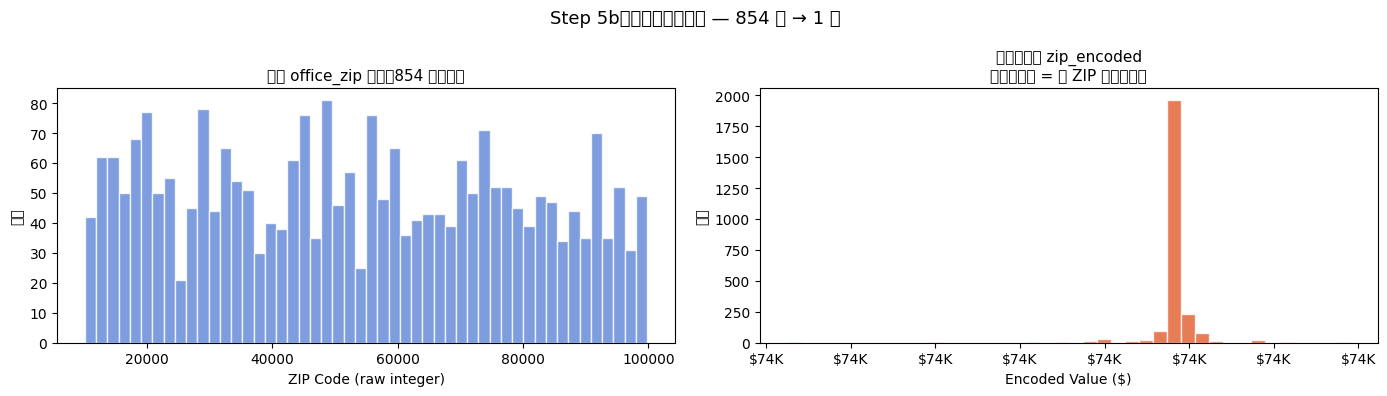


✓ 目标编码完成：将地理位置信息从 854 维压缩为 1 个薪资信号向量


In [14]:
# ── Step 5b: 高基数目标编码（Target Encoding）────────────────
# office_zip 有 854 个唯一值，One-Hot 会产生 853 列（维度爆炸）
# 目标编码：用该 ZIP 对应的平均薪资替换，压缩为 1 个连续向量

print(f'office_zip 唯一值数量：{df["office_zip"].nunique()}')
print('One-Hot 编码将产生 853 列 → 维度爆炸，引入稀疏性问题\n')

# 目标编码器（用训练集的目标均值替换类别标签）
encoder = ce.TargetEncoder(cols=['office_zip'], smoothing=1.0)

df_enc = df.dropna(subset=['base_salary', 'office_zip']).copy()
df_enc['zip_encoded'] = encoder.fit_transform(
    df_enc[['office_zip']], df_enc['base_salary']
)

print('目标编码后，zip_encoded 的统计描述：')
print(df_enc['zip_encoded'].describe().round(2))

# 可视化：原始 ZIP vs 编码后的平均薪资
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_enc['office_zip'], bins=50, color='#5c85d6', edgecolor='white', alpha=0.8)
axes[0].set_title('原始 office_zip 分布（854 个类别）', fontsize=11)
axes[0].set_xlabel('ZIP Code (raw integer)')
axes[0].set_ylabel('频率')

axes[1].hist(df_enc['zip_encoded'], bins=40, color='#e05c2d', edgecolor='white', alpha=0.8)
axes[1].set_title('目标编码后 zip_encoded\n（连续向量 = 该 ZIP 平均薪资）', fontsize=11)
axes[1].set_xlabel('Encoded Value ($)')
axes[1].set_ylabel('频率')
axes[1].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))

plt.suptitle('Step 5b：高基数目标编码 — 854 列 → 1 列', fontsize=13)
plt.tight_layout()
plt.savefig('target_encoding.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n✓ 目标编码完成：将地理位置信息从 854 维压缩为 1 个薪资信号向量')

## Step 6: Streamlit 交互式仪表板代码（AI 扩展任务）

以下是完整的 Streamlit 应用代码，满足 P.R.I.M.E. 扩展任务要求：
- 支持 CSV 上传 → 动态缺失矩阵 → 一键条件归因

In [15]:
# ── Streamlit 应用代码（保存为 app.py 在本地运行）────────────
# 在 Colab 中展示代码内容，本地运行请执行：streamlit run app.py

streamlit_code = '''
# app.py — 交互式缺失数据取证仪表板
# 本地启动：streamlit run app.py

import streamlit as st
import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

st.set_page_config(page_title="缺失数据取证仪表板", layout="wide")
st.title("🔍 缺失数据取证 & 条件归因仪表板")
st.markdown("上传 CSV 文件，自动生成缺失矩阵，并执行按部门条件中位数归因。")

# ─── @st.cache_data ───────────────────────────────────────────
# 说明：@st.cache_data 会将函数的返回值（DataFrame）缓存到磁盘。
# 只要传入的 file_bytes 不变（相同文件），Streamlit 就直接返回缓存结果，
# 避免每次交互时重新解析 CSV，显著提升响应速度。
@st.cache_data
def load_csv(file_bytes):
    """解析上传的 CSV 字节流并返回 DataFrame（结果被缓存）"""
    import io
    return pd.read_csv(io.BytesIO(file_bytes))

# ─── 文件上传 ─────────────────────────────────────────────────
uploaded_file = st.file_uploader("上传 CSV 文件", type=["csv"])

if uploaded_file is not None:
    # ─── st.session_state ─────────────────────────────────────
    # 说明：session_state 在同一用户会话中跨 re-run 持久保存变量。
    # 当用户点击"执行归因"按钮触发 re-run 时，原始 df 不会丢失，
    # imputed_df 也能独立保存，支持对比原始 vs 归因后的状态。
    if 'df' not in st.session_state:
        st.session_state.df = load_csv(uploaded_file.read())

    df = st.session_state.df

    # ─── 基本统计 ─────────────────────────────────────────────
    col1, col2, col3 = st.columns(3)
    col1.metric("总行数", df.shape[0])
    col2.metric("总列数", df.shape[1])
    col3.metric("含缺失值列数", df.isnull().any().sum())

    st.subheader("缺失值摘要")
    missing_summary = pd.DataFrame({
        '缺失数量': df.isnull().sum(),
        '缺失率(%)': (df.isnull().sum() / len(df) * 100).round(2)
    }).query('缺失数量 > 0')
    st.dataframe(missing_summary)

    # ─── 缺失矩阵可视化 ───────────────────────────────────────
    st.subheader("缺失矩阵（视觉取证）")
    fig, ax = plt.subplots(figsize=(12, 5))
    msno.matrix(df, ax=ax, sparkline=False, fontsize=10,
                color=(0.25, 0.45, 0.75))
    ax.set_title("白色间隙的结构对齐 → 识别 MAR 机制", fontsize=12)
    st.pyplot(fig)

    # ─── 条件归因 ─────────────────────────────────────────────
    st.subheader("条件中位数归因")

    # 动态检测数值列和可能的分组列
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    cat_cols = df.select_dtypes(include='object').columns.tolist()

    target_col = st.selectbox("选择需要归因的数值列", numeric_cols)
    group_col = st.selectbox("按此列分组归因", cat_cols)

    if st.button("▶ 执行条件中位数归因"):
        # 执行分组归因，结果存入 session_state 以持久保存
        df_imputed = df.copy()
        df_imputed[target_col] = df_imputed.groupby(group_col)[target_col].transform(
            lambda x: x.fillna(x.median())
        )
        st.session_state.imputed_df = df_imputed

        remaining = df_imputed[target_col].isnull().sum()
        st.success(f"✅ 归因完成！{target_col} 剩余缺失值：{remaining}")

        # 归因前后对比
        st.write("归因前后统计对比：")
        compare = pd.DataFrame({
            '归因前': df[target_col].describe(),
            '归因后': df_imputed[target_col].describe()
        }).round(2)
        st.dataframe(compare)

        st.download_button(
            "⬇ 下载归因后数据集 (CSV)",
            df_imputed.to_csv(index=False),
            file_name="imputed_data.csv",
            mime="text/csv"
        )
else:
    st.info("请上传 CSV 文件以开始分析。")
'''

# 将 Streamlit 代码保存为 app.py 文件
with open('app.py', 'w', encoding='utf-8') as f:
    f.write(streamlit_code)

print('✓ app.py 已保存到当前目录')
print('\n本地启动步骤：')
print('  1. pip install streamlit missingno pandas')
print('  2. streamlit run app.py')
print('  3. 浏览器自动打开 http://localhost:8501')
print('\n界面说明：')
print('  - 上方 3 个指标卡：总行数 / 列数 / 含缺失列数')
print('  - 缺失值摘要表：仅显示有缺失的列及其比例')
print('  - 动态缺失矩阵：实时渲染，支持任意 CSV')
print('  - 下拉选择 + 按钮：选择目标列和分组列，一键执行条件归因')
print('  - 归因后可下载清洗后的 CSV 文件')

✓ app.py 已保存到当前目录

本地启动步骤：
  1. pip install streamlit missingno pandas
  2. streamlit run app.py
  3. 浏览器自动打开 http://localhost:8501

界面说明：
  - 上方 3 个指标卡：总行数 / 列数 / 含缺失列数
  - 缺失值摘要表：仅显示有缺失的列及其比例
  - 动态缺失矩阵：实时渲染，支持任意 CSV
  - 下拉选择 + 按钮：选择目标列和分组列，一键执行条件归因
  - 归因后可下载清洗后的 CSV 文件
